# Imports

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import sys
print(sys.executable)

C:\Users\erics\OneDrive\Bureau\Cursus\3e_ESGI\s2\PA\projet_annuel\projet_annuel_IABD\python_client\.venv\Scripts\python.exe


In [5]:
import os
import numpy as np
from cffi import FFI
ffi = FFI()
ffi.cdef("""
    void* create_rosenblatt(
        size_t n_features,
        float learning_rate,
        float bias,
        uint64_t seed
    );

    void train_rosenblatt(
        void* classifier,
        const float* x,
        size_t rows,
        size_t cols,
        const int* y,
        size_t y_len,
        size_t epochs
    );

    float* predict_rosenblatt(
        void* rosenblatt,
        const float* x,
        size_t rows,
        size_t cols
    );
    
    typedef struct {
        float* data;
        size_t rows;
        size_t cols;
    } MatrixFFIRos;
    
    MatrixFFIRos* transforming_ros(
        const float* x,
        size_t rows,
        size_t cols
    );
    
    void release_matrix_ffi(
        MatrixFFIRos* matrix
    );
    
""", override=True)
dll_path = os.path.abspath("../felidae_classifier/target/debug/felidae_classifier.dll")
lib = ffi.dlopen(dll_path)

# Cas de tests, rendu 2

## Classification

### Linear Simple :
        Linear Model : OK
        MLP (2, 1)   : OK

In [6]:
X = np.array([
      [1, 1],
      [2, 3],
      [3, 3]
])
Y = np.array([
      1,
      -1,
      -1
])


rosenblatt = lib.create_rosenblatt(
    X.shape[1],
    1.0,
    1.0,
    200
)
X = X.astype(np.float32)
Y = Y.astype(np.int32)
X_ptr = ffi.from_buffer("float[]", X)
Y_ptr = ffi.from_buffer("int[]", Y)

lib.train_rosenblatt(
    rosenblatt,
    X_ptr,
    X.shape[0],
    X.shape[1],
    Y_ptr,
    Y.shape[0],
    1000
)

linear_test = lib.predict_rosenblatt(
    rosenblatt,
    X_ptr,
    X.shape[0],
    X.shape[1]
)

pred_linear = np.frombuffer(
    ffi.buffer(linear_test, X.shape[0] * ffi.sizeof("float")),
    dtype = np.float32
)
pred_linear = np.where(pred_linear > 0, 1, -1)
print(pred_linear)
if np.array_equal(pred_linear, Y):
    print("OK")
else:
    print("KO")

[ 1 -1 -1]
OK


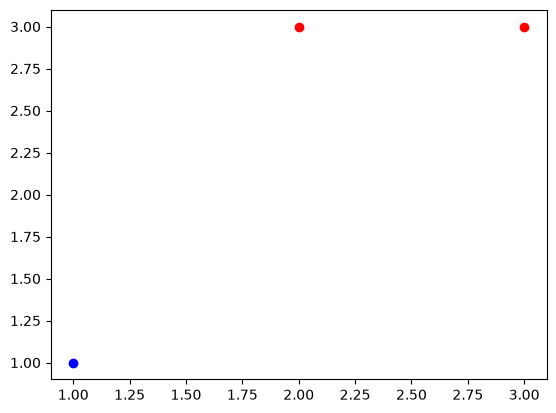

<Figure size 640x480 with 0 Axes>

In [39]:
plt.scatter(X[0, 0], X[0, 1], color='blue')
plt.scatter(X[1:3,0], X[1:3,1], color='red')
plt.show()
plt.clf()

### Linear Multiple :
        Linear Model : OK
        MLP (2, 1)   : OK

In [40]:
X = np.concatenate([np.random.random((50,2)) * 0.9 + np.array([1, 1]), np.random.random((50,2)) * 0.9 + np.array([2, 2])])
Y = np.concatenate([np.ones((50, 1)), np.ones((50, 1)) * -1.0])


rosenblatt = lib.create_rosenblatt(
    X.shape[1],
    1.0,
    1.0,
    200
)
X = X.astype(np.float32)
Y = Y.astype(np.int32)
X_ptr = ffi.from_buffer("float[]", X)
Y_ptr = ffi.from_buffer("int[]", Y)

lib.train_rosenblatt(
    rosenblatt,
    X_ptr,
    X.shape[0],
    X.shape[1],
    Y_ptr,
    Y.shape[0],
    1000
)

linear_test = lib.predict_rosenblatt(
    rosenblatt,
    X_ptr,
    X.shape[0],
    X.shape[1]
)

pred_linear = np.frombuffer(
    ffi.buffer(linear_test, X.shape[0] * ffi.sizeof("float")),
    dtype = np.float32
)
pred_linear = np.where(pred_linear > 0, 1, -1)
print(pred_linear)
if np.array_equal(pred_linear, Y.flatten()):
    print("OK")
else:
    print("KO")

[ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1]
OK


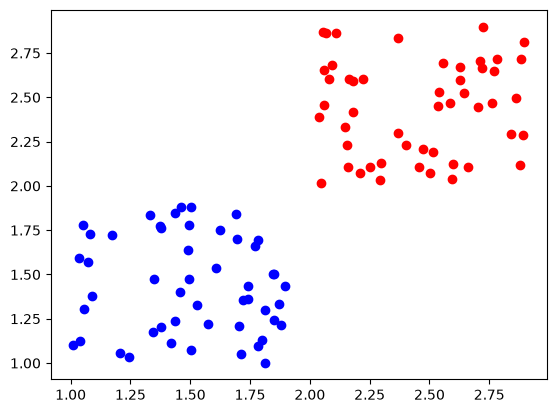

<Figure size 640x480 with 0 Axes>

In [41]:
plt.scatter(X[0:50, 0], X[0:50, 1], color='blue')
plt.scatter(X[50:100,0], X[50:100,1], color='red')
plt.show()
plt.clf()

### XOR :
        Linear Model    : KO
        MLP (2, 2, 1)   : OK

In [70]:
X = np.array([[1, 0], [0, 1], [0, 0], [1, 1]])
Y = np.array([1, 1, -1, -1])

X = X.astype(np.float32)
Y = Y.astype(np.int32)
X_ptr = ffi.from_buffer("float[]", X)
Y_ptr = ffi.from_buffer("int[]", Y)
result = lib.transforming_ros(X_ptr, X.shape[0], X.shape[1])
new_X = np.frombuffer(
    ffi.buffer(result.data, result.rows * result.cols * ffi.sizeof("float")),
    dtype = np.float32
).reshape(result.rows, result.cols)

rosenblatt = lib.create_rosenblatt(
    result.cols,
    0.01,
    1.0,
    200
)

lib.train_rosenblatt(
    rosenblatt,
    result.data,
    result.rows,
    result.cols,
    Y_ptr,
    Y.shape[0],
    500
)

pred = lib.predict_rosenblatt(
    rosenblatt,
    result.data,
    result.rows,
    result.cols
)

pred_result = np.frombuffer(
    ffi.buffer(pred, result.rows * ffi.sizeof("float")),
    dtype = np.float32
)
print(pred_result)
pred_result = np.where(pred_result > 0, 1, -1)
print(pred_result)
if np.array_equal(pred_result, Y):
    print("OK")
else:
    print("KO")

[ 0.03850594  0.03279692 -0.00617397 -0.01906748]
[ 1  1 -1 -1]
OK


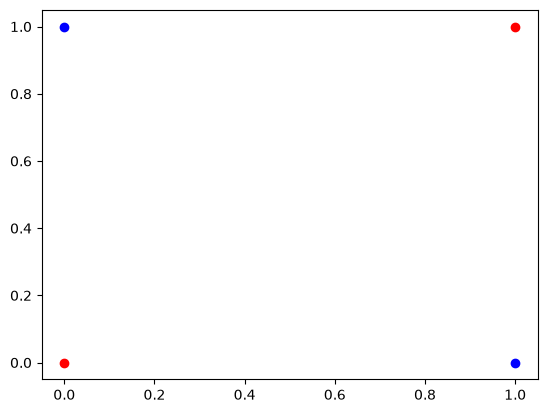

<Figure size 640x480 with 0 Axes>

In [43]:
plt.scatter(X[0:2, 0], X[0:2, 1], color='blue')
plt.scatter(X[2:4,0], X[2:4,1], color='red')
plt.show()
plt.clf()


### Cross :
        Linear Model    : KO
        MLP (2, 4, 1)   : OK

In [23]:
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([1 if abs(p[0]) <= 0.3 or abs(p[1]) <= 0.3 else -1 for p in X])
print(Y)
X = X.astype(np.float32)
Y = Y.astype(np.int32)
X_ptr = ffi.from_buffer("float[]", X)
Y_ptr = ffi.from_buffer("int[]", Y)
result = lib.transforming_ros(X_ptr, X.shape[0], X.shape[1])
new_X = np.frombuffer(
    ffi.buffer(result.data, result.rows * result.cols * ffi.sizeof("float")),
    dtype = np.float32
).reshape(result.rows, result.cols)

rosenblatt = lib.create_rosenblatt(
    result.cols,
    0.01,
    1.0,
    200
)

lib.train_rosenblatt(
    rosenblatt,
    result.data,
    result.rows,
    result.cols,
    Y_ptr,
    Y.shape[0],
    500
)

pred = lib.predict_rosenblatt(
    rosenblatt,
    result.data,
    result.rows,
    result.cols
)

pred_result = np.frombuffer(
    ffi.buffer(pred, result.rows * ffi.sizeof("float")),
    dtype = np.float32
)
print(pred_result)
pred_result = np.where(pred_result > 0, 1, -1)
print(pred_result)
if np.array_equal(pred_result, Y.flatten()):
    print("OK")
else:
    print("KO")

[ 1 -1  1 -1  1 -1  1  1  1  1  1  1  1 -1 -1  1 -1 -1  1  1  1 -1  1  1
  1  1  1  1  1 -1 -1  1 -1  1  1 -1  1 -1 -1 -1 -1  1  1 -1  1 -1  1  1
 -1  1 -1  1  1 -1 -1  1 -1  1  1  1  1 -1 -1 -1 -1 -1 -1 -1  1 -1  1 -1
  1 -1 -1 -1  1  1  1 -1 -1  1  1 -1  1 -1  1  1  1 -1 -1 -1 -1  1  1  1
  1  1  1  1  1 -1 -1  1 -1  1  1  1 -1  1 -1  1 -1  1  1 -1  1 -1 -1 -1
  1  1  1  1 -1 -1 -1  1  1  1 -1  1 -1  1 -1 -1  1  1 -1 -1  1 -1 -1 -1
  1  1 -1  1 -1  1 -1  1 -1  1  1 -1  1 -1 -1 -1  1 -1  1  1  1 -1 -1 -1
 -1  1 -1 -1  1  1 -1  1 -1 -1 -1  1 -1 -1 -1 -1  1 -1  1  1 -1 -1  1  1
 -1 -1 -1 -1 -1 -1 -1 -1 -1  1  1 -1 -1 -1  1 -1  1 -1  1  1  1 -1 -1  1
 -1  1 -1  1 -1  1  1  1  1  1  1 -1  1  1  1 -1 -1 -1 -1 -1  1  1  1 -1
  1  1 -1  1  1  1  1  1 -1  1  1  1  1 -1 -1  1 -1  1 -1 -1 -1 -1  1  1
 -1  1  1  1  1 -1 -1  1  1  1 -1 -1  1 -1  1 -1  1 -1 -1  1  1 -1  1  1
 -1 -1 -1 -1 -1  1 -1  1 -1  1 -1 -1 -1 -1  1  1  1 -1  1 -1 -1  1  1  1
  1  1 -1  1 -1 -1  1 -1  1 -1 -1 -1  1 -1  1 -1  1

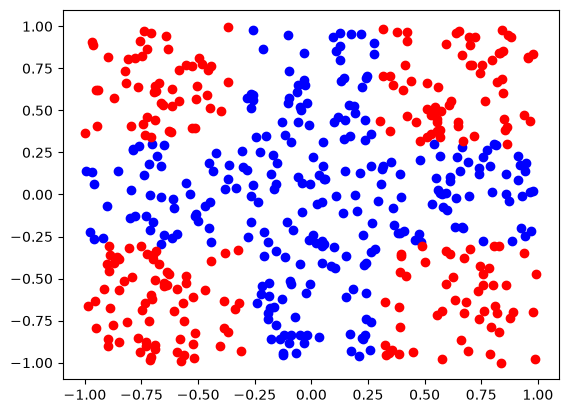

<Figure size 640x480 with 0 Axes>

In [47]:
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,1], color='red')
plt.show()
plt.clf()

### Multi Linear 3 classes :
        Linear Model x3 : OK
        MLP (2, 3)      : OK

In [26]:
import os
import numpy as np
from cffi import FFI
ffi = FFI()
ffi.cdef("""
    void* create_rosenblatt_classifier(
        size_t n_features,
        float learning_rate,
        float bias_cat,
        float bias_lion,
        float bias_cheetah,
        uint64_t seed
    );

    void train_classifier(
        void* classifier,
        const float* x,
        size_t rows,
        size_t cols,
        const size_t* y,
        size_t y_len,
        size_t epochs
    );

    size_t* predict_classifier(
        void* classifier,
        const float* x,
        size_t rows,
        size_t cols,
        const size_t* y,
        size_t y_len
    );
    typedef struct {
        float* data;
        size_t rows;
        size_t cols;
    } MatrixFFI;
    MatrixFFI* transforming(void* classifier, const float* x, size_t rows, size_t cols);
    void release_matrix_ffi(MatrixFFI* matrix);
    
""", override=True)

dll_path = os.path.abspath("../felidae_classifier/target/debug/felidae_classifier.dll")
lib = ffi.dlopen(dll_path)

In [18]:
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([[1, -1, -1] if -p[0] - p[1] - 0.5 > 0 and p[1] < 0 and p[0] - p[1] - 0.5 < 0 else
              [-1, 1, -1] if -p[0] - p[1] - 0.5 < 0 and p[1] > 0 and p[0] - p[1] - 0.5 < 0 else
              [-1, -1, 1] if -p[0] - p[1] - 0.5 < 0 and p[1] < 0 and p[0] - p[1] - 0.5 > 0 else
              [-1, -1, -1]for p in X])

X = X[[not np.all(arr == [-1, -1, -1]) for arr in Y]]
Y = Y[[not np.all(arr == [-1, -1, -1]) for arr in Y]]

print("y de base",Y)

X_ffi = np.ascontiguousarray(X, dtype=np.float32)
Y_ffi = np.ascontiguousarray(np.argmax(Y, axis=1), dtype=np.uint64)
print("y ffi ",Y_ffi)
X_ptr = ffi.from_buffer("float[]", X_ffi)
Y_ptr = ffi.from_buffer("size_t[]", Y_ffi)

classifier = lib.create_rosenblatt_classifier(X.shape[1], 0.01, 1.0, 1.0, 1.0, 200)
lib.train_classifier(
    classifier,
    X_ptr,
    X_ffi.shape[0],
    X_ffi.shape[1],
    Y_ptr,
    Y_ffi.shape[0],
    100
)

pred_brut = lib.predict_classifier(classifier,
    X_ptr,
    X_ffi.shape[0],
    X_ffi.shape[1],
    Y_ptr,
    Y_ffi.shape[0]
)

pred_form = np.frombuffer(
    ffi.buffer(pred_brut, X_ffi.shape[0] * ffi.sizeof("size_t")),
    dtype=np.uintp
)
print("prediction form",pred_form)

if np.array_equal(pred_form.flatten(), Y_ffi):
    print("OK")
else:
    print("KO")


y de base [[-1 -1  1]
 [ 1 -1 -1]
 [-1  1 -1]
 ...
 [-1  1 -1]
 [-1 -1  1]
 [-1  1 -1]]
y ffi  [2 0 1 1 1 1 0 1 1 2 2 0 1 1 0 1 1 1 1 1 1 1 1 2 2 1 1 0 2 1 1 1 1 1 1 1 1
 1 2 1 1 1 2 0 1 1 1 1 2 1 1 1 1 1 0 2 0 1 0 1 1 1 0 1 0 0 2 1 1 2 1 1 2 2
 1 1 0 1 0 1 1 1 1 1 0 2 1 1 1 1 1 0 1 1 2 0 2 1 1 1 0 1 1 1 1 0 1 0 1 0 2
 2 2 1 0 1 0 0 0 1 1 2 1 2 1 1 1 1 0 0 1 1 1 1 1 1 2 0 1 1 2 2 0 1 2 0 2 1
 0 1 2 2 0 2 0 1 1 1 0 1 1 1 2 1 1 1 1 1 0 1 2 0 0 2 1 2 0 1 1 2 1 2 2 1 2
 2 2 1 2 0 2 2 0 1 1 1 1 0 0 1 0 2 0 1 1 1 1 1 1 2 2 1 1 2 1 2 1 1 0 2 1 1
 1 1 1 2 0 0 1 1 1 1 1 2 0 0 0 2 1 1 2 0 2 2 1 0 1 0 0 2 1 1 1 2 1 2 1 0 2
 2 0 2 1 1 0 2 2 2 2 1 0 1 1 0 1 1 1 0 0 1 1 2 1 1 1 1 1 0 1 1 0 1 1 0 0 1
 0 0 1 0 1 1 1 1 1 1 2 0 2 1 1 0 1 0 0 1 2 0 0 1 0 2 0 1 0 1 1 1 1 1 0 2 1
 1 0 1 1 1 1 1 1 0 0 1 1 1 0 2 1 1 0 1 2 0 1 1 2 0 1 1 1 2 1 1 2 2 1 1 1 1
 1 1 0 1 1 1 0 0 1 1 2 1 0 2 1 2 1 0 0 1 2 1 1 1 1 2 0 1 1 2 1 1 1 2 1]
prediction form [2 0 1 1 1 1 0 1 1 2 2 0 1 1 0 1 1 1 1 1 1 1 1 2 2 1 1 0 2 1 1 1 1 

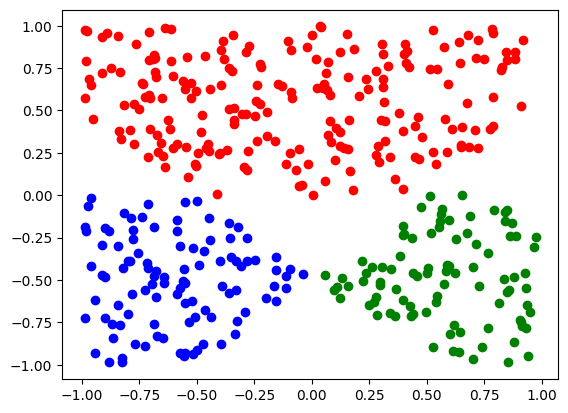

<Figure size 640x480 with 0 Axes>

In [142]:
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,1], color='red')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,1], color='green')
plt.show()
plt.clf()

### Multi Cross :
        Linear Model x3 : KO
        MLP (2, ?, ?, 3): OK

In [27]:
X = np.random.random((1000, 2)) * 2.0 - 1.0
Y = np.array([[1, -1, -1] if abs(p[0] % 0.5) <= 0.25 and abs(p[1] % 0.5) > 0.25 else [-1, 1, -1] if abs(p[0] % 0.5) > 0.25 and abs(p[1] % 0.5) <= 0.25 else [-1, -1, 1] for p in X])

print("y de base",Y)

X_ffi = np.ascontiguousarray(X, dtype=np.float32)
Y_ffi = np.ascontiguousarray(np.argmax(Y, axis=1), dtype=np.uint64)
print("y ffi ",Y_ffi)
X_ptr = ffi.from_buffer("float[]", X_ffi)
Y_ptr = ffi.from_buffer("size_t[]", Y_ffi)

classifier = lib.create_rosenblatt_classifier(X.shape[1], 0.01, 1.0, 1.0, 1.0, 200)
lib.train_classifier(
    classifier,
    X_ptr,
    X_ffi.shape[0],
    X_ffi.shape[1],
    Y_ptr,
    Y_ffi.shape[0],
    100
)

pred_brut = lib.predict_classifier(classifier,
    X_ptr,
    X_ffi.shape[0],
    X_ffi.shape[1],
    Y_ptr,
    Y_ffi.shape[0]
)

pred_form = np.frombuffer(
    ffi.buffer(pred_brut, X_ffi.shape[0] * ffi.sizeof("size_t")),
    dtype=np.uintp
)
print("prediction form",pred_form)

if np.array_equal(pred_form.flatten(), Y_ffi):
    print("OK")
else:
    print("KO")


y de base [[-1  1 -1]
 [ 1 -1 -1]
 [-1 -1  1]
 ...
 [-1 -1  1]
 [-1 -1  1]
 [-1  1 -1]]
y ffi  [1 0 2 2 0 2 2 1 2 2 2 2 0 0 0 2 2 2 2 2 0 0 2 2 2 1 2 2 0 2 2 1 2 0 1 2 2
 0 2 2 1 1 2 2 0 1 2 2 2 1 2 2 1 2 1 0 2 2 0 1 1 1 0 1 0 2 2 2 0 2 2 2 2 1
 0 1 2 0 1 2 0 1 2 1 2 0 1 1 2 2 2 1 2 0 0 0 0 1 0 2 0 2 2 1 0 2 0 2 1 2 2
 1 2 1 2 2 0 0 0 2 0 2 2 2 0 1 2 1 2 1 0 1 0 1 2 2 1 0 2 1 2 1 1 1 2 2 0 2
 2 1 1 0 2 2 2 2 0 1 0 2 0 2 0 2 2 2 0 0 0 1 0 0 2 0 1 1 2 2 2 2 2 1 2 2 2
 1 1 2 2 2 2 2 1 2 0 2 1 0 2 2 1 2 2 0 2 0 1 2 2 2 1 2 2 1 2 1 2 0 2 2 1 2
 2 0 2 2 2 2 2 1 2 2 2 2 0 0 0 1 1 2 1 1 0 0 1 2 0 0 2 2 2 2 2 0 0 2 2 2 2
 2 2 1 1 1 0 2 0 2 2 2 1 2 2 1 0 2 2 1 1 2 1 2 2 1 2 2 0 0 0 1 0 1 2 2 0 0
 1 0 0 0 0 2 0 1 1 1 2 1 2 1 1 0 2 1 2 0 2 2 1 2 2 1 0 2 2 2 2 2 2 2 1 1 2
 2 1 1 0 2 0 2 2 2 2 1 0 2 2 0 1 0 2 0 1 2 0 2 2 2 1 2 0 0 2 2 0 2 0 2 2 0
 2 2 2 1 2 0 0 0 2 2 2 0 0 2 0 0 1 0 0 0 1 0 1 0 2 0 2 1 2 1 0 1 0 0 1 2 1
 2 2 1 2 0 1 2 0 2 2 2 2 2 2 1 2 2 0 2 1 2 1 2 2 1 1 0 2 2 1 2 0 2 2 2 2 0
 0 1 

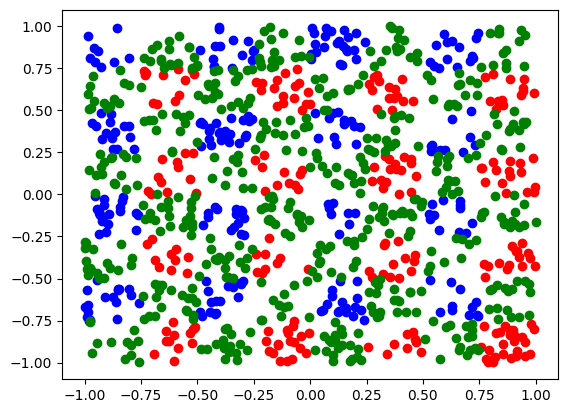

<Figure size 640x480 with 0 Axes>

In [144]:
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,1], color='red')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,1], color='green')
plt.show()
plt.clf()

## Régression

### Linear Simple 2D :
        Linear Model : OK
        MLP (1, 1)   : OK

In [2]:
import matplotlib.pyplot as plt
import numpy as np

import os
import numpy as np
from cffi import FFI
ffi = FFI()
ffi.cdef("""
    typedef struct{
        float* data;
        size_t rows;
        size_t cols;
    }MatrixFFIRegression;
    
    void* create_regression(
        size_t nb_feature
    );

    void fit_regression(
        void* regression,
        const float* x,
        size_t x_rows,
        size_t x_cols,
        const float* y,
        size_t y_len,
        float bias  
    );
    

    MatrixFFIRegression* predict_regression(
        void* regression,
        const float* x,
        size_t x_rows,
        size_t x_cols,
        float bias
    );

    void release_matrix_ffi(
        MatrixFFIRegression* matrix
    );
""", override = True)

dll_path = os.path.abspath("../felidae_classifier/target/debug/felidae_classifier.dll")
lib = ffi.dlopen(dll_path)

In [4]:
X = np.array([
      [1],
      [2]
])
Y = np.array([
      2,
      3
])

X = X.astype(np.float32)
Y = Y.astype(np.float32)

X_ptr = ffi.from_buffer("float[]", X)
Y_ptr = ffi.from_buffer("float[]", Y)

regression = lib.create_regression(
    X.shape[1],
)

lib.fit_regression(
    regression,
    X_ptr,
    X.shape[0],
    X.shape[1],
    Y_ptr,
    Y.shape[0],
    1.0
)

prediction = lib.predict_regression(
    regression,
    X_ptr,
    X.shape[0],
    X.shape[1],
    1.0
)

prediction_form = np.frombuffer(
    ffi.buffer(
        prediction.data,
        prediction.rows * prediction.cols * ffi.sizeof("float")
    ),
    dtype=np.float32
)

if np.array_equal(prediction_form, Y):
    print("OK")
else:
    print("KO")


OK


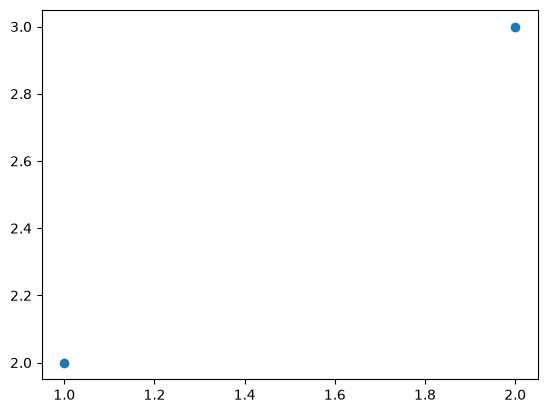

<Figure size 640x480 with 0 Axes>

In [21]:
plt.scatter(X,Y)
plt.show()
plt.clf()

### Non Linear Simple 2D :
        Linear Model    : OK
        MLP (1, ?, 1)   : OK

In [5]:
X = np.array([
      [1],
      [2],
      [3]
])
Y = np.array([
      2,
      3,
      2.5
])


X = X.astype(np.float32)
Y = Y.astype(np.float32)

X_ptr = ffi.from_buffer("float[]", X)
Y_ptr = ffi.from_buffer("float[]", Y)

regression = lib.create_regression(
    X.shape[1],
)

lib.fit_regression(
    regression,
    X_ptr,
    X.shape[0],
    X.shape[1],
    Y_ptr,
    Y.shape[0],
    1.0
)

prediction = lib.predict_regression(
    regression,
    X_ptr,
    X.shape[0],
    X.shape[1],
    1.0
)

prediction_form = np.frombuffer(
    ffi.buffer(
        prediction.data,
        prediction.rows * prediction.cols * ffi.sizeof("float")
    ),
    dtype=np.float32
)


print(Y)
print(prediction_form)

if np.allclose(prediction_form, Y):
    print("OK")
else:
    print("KO")


[2.  3.  2.5]
[2.2499995 2.4999995 2.7499995]
KO


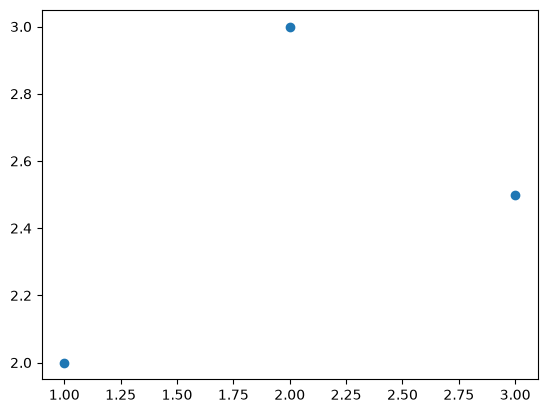

<Figure size 640x480 with 0 Axes>

In [9]:
plt.scatter(X,Y)
plt.show()
plt.clf()

### Linear Simple 3D :
        Linear Model    : OK
        MLP (2, 1)      : OK

In [6]:
X = np.array([
      [1, 1],
      [2, 2],
      [3, 1]
])
Y = np.array([
      2,
      3,
      2.5
])


X = X.astype(np.float32)
Y = Y.astype(np.float32)

X_ptr = ffi.from_buffer("float[]", X)
Y_ptr = ffi.from_buffer("float[]", Y)

regression = lib.create_regression(
    X.shape[1],
)

lib.fit_regression(
    regression,
    X_ptr,
    X.shape[0],
    X.shape[1],
    Y_ptr,
    Y.shape[0],
    1.0
)

prediction = lib.predict_regression(
    regression,
    X_ptr,
    X.shape[0],
    X.shape[1],
    1.0
)

prediction_form = np.frombuffer(
    ffi.buffer(
        prediction.data,
        prediction.rows * prediction.cols * ffi.sizeof("float")
    ),
    dtype=np.float32
)



if np.allclose(prediction_form, Y):
    print("OK")
else:
    print("KO")


OK


In [11]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

### Linear Tricky 3D :
        Linear Model    : OK
        MLP (2, 1)      : OK

In [7]:
X = np.array([
      [1, 1],
      [2, 2],
      [3, 3]
])
Y = np.array([
      1,
      2,
      3
])

In [13]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

### Non Linear Simple 3D :
        Linear Model       : KO
        MLP (2, 2, 1)      : OK

In [14]:
X = np.array([
      [1, 0],
      [0, 1],
      [1, 1],
      [0, 0],
])
Y = np.array([
      2,
      1,
      -2,
      -1
])

In [15]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>